In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools from Scikit-Learn for preprocessing, PCA, and clustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configure plots to look clean and professional
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Generate fake customer data to practice on

# Create a dataset with 4 natural groups of customers using Scikit-Learn
X_raw, y_true = make_blobs(
    n_samples=500,        # We want to generate data for 500 customers
    n_features=4,         # Each customer has 4 features (Age, Income, Spending, Frequency)
    centers=4,            # Generate data around 4 central points (clusters)
    cluster_std=1.5,      # Add some randomness so points overlap naturally
    random_state=42       # Use a fixed seed so we get the exact same data every time we run
)

# Convert raw numbers into realistic customer features
features = {
    'Age': np.round(np.clip((X_raw[:, 0] * 5) + 35, 18, 70)),                 # Ages range from 18 to 70
    'Annual_Income_k': np.round(np.clip((X_raw[:, 1] * 12) + 65, 15, 150)),  # Income ranges from $15k to $150k
    'Spending_Score': np.round(np.clip((X_raw[:, 2] * 15) + 50, 1, 100)),     # Score ranges from 1 to 100
    'Purchase_Frequency': np.round(np.clip((X_raw[:, 3] * 2) + 8, 1, 30))     # Frequency ranges from 1 to 30 times a year
}

# Load the features into a Pandas DataFrame (a clean table)
df = pd.DataFrame(features)

# Print the first 5 rows of our dataset to verify it looks correct
print("--- First 5 Rows of the Dataset ---")
print(df.head())

--- First 5 Rows of the Dataset ---
    Age  Annual_Income_k  Spending_Score  Purchase_Frequency
0  18.0             15.0             1.0                20.0
1  70.0             15.0             1.0                 1.0
2  67.0             21.0             1.0                 1.0
3  38.0            150.0           100.0                15.0
4  46.0             92.0             1.0                25.0


In [3]:
#  Scale features and reduce dimensions using PCA

# Step 1: Scale the features so they all have a mean of 0 and variance of 1
# This is crucial because features like Income are much larger than Age or Frequency
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Step 2: Use PCA to compress our 4 features into fewer components
# We set n_components to 0.95 to keep enough components to capture 95% of the original variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Print the results of our transformation
print(f"Original number of features: {df.shape[1]}")
print(f"Reduced number of features after PCA: {X_pca.shape[1]}")
print(f"Percentage of variance captured by PCA: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Original number of features: 4
Reduced number of features after PCA: 3
Percentage of variance captured by PCA: 99.10%


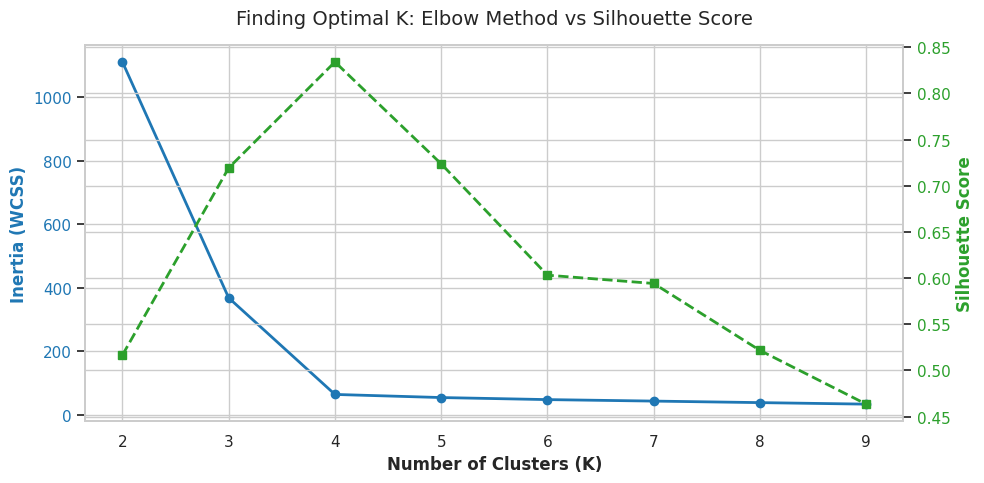

In [4]:
# Calculate and plot the Elbow Method and Silhouette Scores side-by-side

wcss = []                  # List to store the distance of points from their cluster centers
silhouette_scores = []     # List to store how well-separated the clusters are
K_range = range(2, 10)     # Check values of K from 2 up to 9

# Run K-Means for each K value and collect results
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot both helper metrics side-by-side on the same graph
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot 1: The Elbow Method curve (we want to find where the drop slows down)
color = '#1f77b4'
ax1.set_xlabel('Number of Clusters (K)', fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', color=color, fontweight='bold')
ax1.plot(K_range, wcss, marker='o', color=color, linewidth=2, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Finding Optimal K: Elbow Method vs Silhouette Score', fontsize=14, pad=15)

# Plot 2: The Silhouette Score curve (we want to find the peak closest to 1.0)
ax2 = ax1.twinx()
color = '#2ca02c'
ax2.set_ylabel('Silhouette Score', color=color, fontweight='bold')
ax2.plot(K_range, silhouette_scores, marker='s', linestyle='--', color=color, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.show()

In [5]:
# Train the final K-Means model on the best cluster count

# Both the Elbow curve and the Silhouette peak show that K=4 is the best choice
optimal_k = 4

# Train the K-Means model with 4 clusters
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_assignments = kmeans_final.fit_predict(X_pca)

# Add the final cluster assignment as a new column to our original DataFrame
df['Cluster'] = cluster_assignments

# Count and display how many customers fell into each cluster
print("Number of customers assigned to each cluster:")
print(df['Cluster'].value_counts().sort_index())

Number of customers assigned to each cluster:
Cluster
0    125
1    125
2    125
3    125
Name: count, dtype: int64


In [6]:
# Convert abstract cluster centers back to real-world customer values

# Step 1: Get the raw cluster center coordinates from our PCA model
centroids_pca = kmeans_final.cluster_centers_

# Step 2: Reverse the PCA transformation to get scaled features back
centroids_scaled = pca.inverse_transform(centroids_pca)

# Step 3: Reverse the StandardScaler to get the original values back
centroids_original = scaler.inverse_transform(centroids_scaled)

# Convert these converted centers into a clean table to easily read them
centroid_df = pd.DataFrame(
    centroids_original,
    columns=df.columns[:-1], # Use original feature names except for the 'Cluster' column
    index=[f'Cluster {i}' for i in range(optimal_k)]
)

# Print the final real-world averages for each cluster
print("--- Average Customer Characteristics per Cluster (Real Values) ---")
print(centroid_df.round(2))

--- Average Customer Characteristics per Cluster (Real Values) ---
             Age  Annual_Income_k  Spending_Score  Purchase_Frequency
Cluster 0  23.19           150.28           96.28               11.77
Cluster 1  17.87            15.67            0.50               22.92
Cluster 2  66.27            16.49            1.14                1.04
Cluster 3  46.30           114.39            2.26               26.97


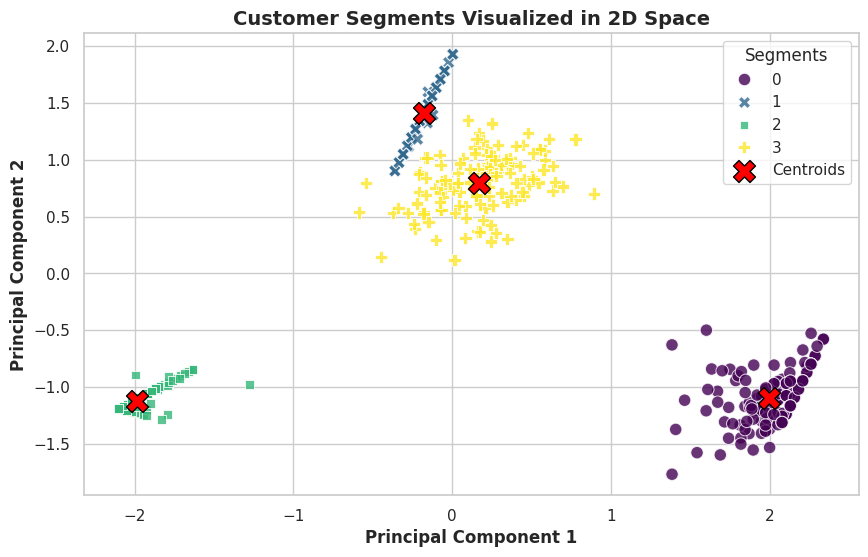

In [7]:
# Plot the customer groups in a 2D graph

plt.figure(figsize=(10, 6))

# Plot the customer data points colored by their assigned cluster
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['Cluster'],
    palette='viridis',
    style=df['Cluster'],
    s=80,
    alpha=0.8
)

# Plot the center (centroid) of each cluster as a big red 'X'
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    marker='X',
    color='red',
    edgecolors='black',
    label='Centroids'
)

# Add labels and a title to the graph
plt.title('Customer Segments Visualized in 2D Space', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontweight='bold')
plt.ylabel('Principal Component 2', fontweight='bold')
plt.legend(title='Segments')
plt.show()